In [ ]:
# ============================================================
# Clasificador de Sentimiento con Atención Q, K, V
# Google Colab — listo para ejecutar
# ============================================================

# ── 1. Instalar dependencias ──────────────────────────────────
!pip install seaborn --quiet

# ── 2. Imports ────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter


In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

# ── 3. Dataset de entrenamiento ───────────────────────────────
# 0 = negativo, 1 = positivo
datos = [
    # Positivos
    ("la pelicula fue increible y muy emocionante",       1),
    ("me encanto la actuacion de todos los actores",      1),
    ("excelente historia con un final sorprendente",      1),
    ("muy buena pelicula la recomiendo ampliamente",      1),
    ("hermosa historia que me llego al corazon",          1),
    ("fantastica actuacion y una trama brillante",        1),
    ("me gusto mucho fue una experiencia maravillosa",    1),
    ("increible pelicula llena de emociones positivas",   1),
    ("buena pelicula con excelentes efectos especiales",  1),
    ("la mejor pelicula que he visto en mucho tiempo",    1),
    ("una obra maestra del cine moderno",                 1),
    ("actuaciones brillantes y guion perfecto",           1),
    ("me encanto cada escena fue perfecta",               1),
    ("pelicula hermosa con mensaje muy poderoso",         1),
    ("excelente produccion y actuaciones memorables",     1),

    # Negativos
    ("la pelicula fue aburrida y muy larga",              0),
    ("no me gusto para nada la actuacion",                0),
    ("pesima historia con un final decepcionante",        0),
    ("muy mala pelicula no la recomiendo",                0),
    ("terrible actuacion y trama sin sentido",            0),
    ("me aburri mucho fue una perdida de tiempo",         0),
    ("horrible pelicula llena de escenas innecesarias",   0),
    ("mala pelicula con efectos especiales pobres",       0),
    ("la peor pelicula que he visto en mi vida",          0),
    ("completamente decepcionante y mal actuada",         0),
    ("guion terrible y direccion muy mala",               0),
    ("no me gusto nada fue muy aburrida",                 0),
    ("pelicula horrible sin ningun momento bueno",        0),
    ("muy decepcionante esperaba mucho mas",              0),
    ("pesima produccion y actuaciones olvidables",        0),
]

print(f"Total oraciones: {len(datos)}")
print(f"Positivas: {sum(1 for _, l in datos if l == 1)}")
print(f"Negativas: {sum(1 for _, l in datos if l == 0)}")

Usando: cpu
Total oraciones: 30
Positivas: 15
Negativas: 15


In [20]:
# ── 4. Construir vocabulario ──────────────────────────────────
def tokenizar(texto):
    return texto.lower().split()

# Contar todas las palabras
todas_palabras = []
for texto, _ in datos:
    todas_palabras.extend(tokenizar(texto))

conteo   = Counter(todas_palabras)
vocab    = ['<PAD>', '<UNK>'] + sorted(conteo.keys())
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}

VOCAB_SIZE = len(vocab)
PAD_IDX    = word2idx['<PAD>']
UNK_IDX    = word2idx['<UNK>']

print(f"\nVocabulario: {VOCAB_SIZE} palabras")

# ── 5. Codificar y padear secuencias ──────────────────────────
MAX_LEN = 12   # longitud máxima de oración

def codificar(texto, max_len=MAX_LEN):
    tokens  = tokenizar(texto)
    indices = [word2idx.get(t, UNK_IDX) for t in tokens]
    # Padear o truncar
    if len(indices) < max_len:
        indices += [PAD_IDX] * (max_len - len(indices))
    else:
        indices = indices[:max_len]
    return indices

# Preparar tensores
X = torch.tensor([codificar(t) for t, _ in datos], dtype=torch.long)
Y = torch.tensor([l for _, l in datos],             dtype=torch.long)

print(f"Forma X: {X.shape}")   # (30, 12)
print(f"Forma Y: {Y.shape}")   # (30,)


Vocabulario: 95 palabras
Forma X: torch.Size([30, 12])
Forma Y: torch.Size([30])


In [23]:
# ── 6, 7 y 8 REESCRITOS COMPLETOS ────────────────────────────

# ── Atención Q, K, V ─────────────────────────────────────────
class AtencionQKV(nn.Module):
    def __init__(self, d_model, d_k):
        super().__init__()
        self.W_Q = nn.Linear(d_model, d_k, bias=False)
        self.W_K = nn.Linear(d_model, d_k, bias=False)
        self.W_V = nn.Linear(d_model, d_k, bias=False)
        self.d_k = d_k

    def forward(self, x, pad_mask=None):
        Q = self.W_Q(x)    # (batch, seq, d_k)
        K = self.W_K(x)    # (batch, seq, d_k)
        V = self.W_V(x)    # (batch, seq, d_k)

        # similitud
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)  # (batch, seq, seq)

        # enmascarar padding
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask, float('-inf'))

        pesos  = F.softmax(scores, dim=-1)   # (batch, seq, seq)
        salida = torch.matmul(pesos, V)      # (batch, seq, d_k)

        return salida, pesos


# ── Modelo completo ───────────────────────────────────────────
class ClasificadorSentimiento(nn.Module):
    def __init__(self, vocab_size, d_model, d_k, n_clases, pad_idx):
        super().__init__()
        self.pad_idx      = pad_idx
        self.embedding    = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.atencion     = AtencionQKV(d_model, d_k)
        self.clasificador = nn.Sequential(
            nn.Linear(d_k, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, n_clases)
        )

    def forward(self, x):
        # ── Máscara: True donde HAY padding (queremos ignorar esos) ──
        # forma: (batch, seq) → True en posiciones PAD
        pad_mask = (x == self.pad_idx)                          # (batch, seq)
        pad_mask = pad_mask.unsqueeze(1).expand(-1, x.size(1), -1)  # (batch, seq, seq)

        # ── Embedding ──
        emb = self.embedding(x)                                 # (batch, seq, d_model)

        # ── Atención ──
        ctx, pesos = self.atencion(emb, pad_mask)              # (batch, seq, d_k)

        # ── Promedio solo sobre tokens reales (no padding) ──
        # mascara booleana de tokens reales: (batch, seq, 1)
        token_mask   = (x != self.pad_idx).float().unsqueeze(2)     # (batch, seq, 1)
        ctx_masked   = ctx * token_mask                              # anular padding
        suma         = ctx_masked.sum(dim=1)                         # (batch, d_k)
        longitudes   = token_mask.sum(dim=1)                         # (batch, 1)
        ctx_promedio = suma / longitudes                             # (batch, d_k)

        # ── Clasificar ──
        logits = self.clasificador(ctx_promedio)                # (batch, n_clases)

        return logits, pesos


# ── Instanciar ────────────────────────────────────────────────
D_MODEL  = 32
D_K      = 16
N_CLASES = 2

modelo = ClasificadorSentimiento(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    d_k=D_K,
    n_clases=N_CLASES,
    pad_idx=PAD_IDX
).to(device)

total_params = sum(p.numel() for p in modelo.parameters())
print(f"Parámetros totales: {total_params:,}")

# ── Verificar formas antes de entrenar ────────────────────────
modelo.eval()
with torch.no_grad():
    test_out, test_pesos = modelo(X[:2].to(device))
    print(f"✅ Salida logits:  {test_out.shape}")    # debe ser (2, 2)
    print(f"✅ Pesos atención: {test_pesos.shape}")  # debe ser (2, 12, 12)



Parámetros totales: 5,186
✅ Salida logits:  torch.Size([2, 2])
✅ Pesos atención: torch.Size([2, 12, 12])



🚀 Entrenando...

Época [010/200]  loss: 0.3336  acc: 96.7%
Época [020/200]  loss: 0.1179  acc: 100.0%
Época [030/200]  loss: 0.0306  acc: 100.0%
Época [040/200]  loss: 0.0052  acc: 100.0%
Época [050/200]  loss: 0.0039  acc: 100.0%
Época [060/200]  loss: 0.0063  acc: 100.0%
Época [070/200]  loss: 0.0029  acc: 100.0%
Época [080/200]  loss: 0.0026  acc: 100.0%
Época [090/200]  loss: 0.0024  acc: 100.0%
Época [100/200]  loss: 0.0022  acc: 100.0%
Época [110/200]  loss: 0.0011  acc: 100.0%
Época [120/200]  loss: 0.0019  acc: 100.0%
Época [130/200]  loss: 0.0014  acc: 100.0%
Época [140/200]  loss: 0.0015  acc: 100.0%
Época [150/200]  loss: 0.0011  acc: 100.0%
Época [160/200]  loss: 0.0024  acc: 100.0%
Época [170/200]  loss: 0.0017  acc: 100.0%
Época [180/200]  loss: 0.0022  acc: 100.0%
Época [190/200]  loss: 0.0021  acc: 100.0%
Época [200/200]  loss: 0.0017  acc: 100.0%


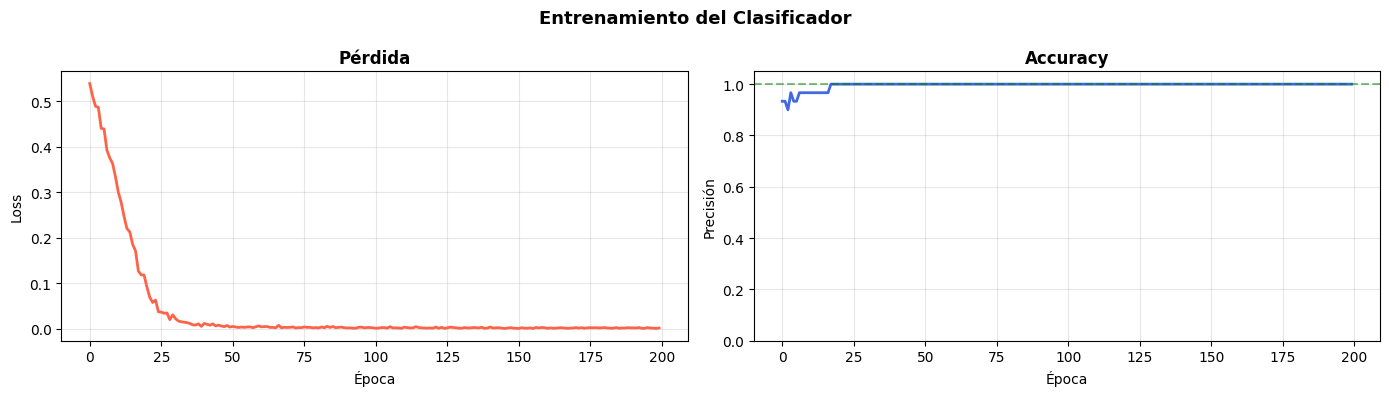

In [27]:
# ── 9. Entrenamiento ──────────────────────────────────────────
EPOCHS = 200
LR     = 3e-3

optimizador = torch.optim.Adam(modelo.parameters(), lr=LR)
criterio    = nn.CrossEntropyLoss()
scheduler   = torch.optim.lr_scheduler.StepLR(optimizador, step_size=25, gamma=0.5)

X = X.to(device)
Y = Y.to(device)

historial_loss = []
historial_acc  = []

print("\n🚀 Entrenando...\n")

for epoch in range(1, EPOCHS + 1):
    modelo.train()

    logits, _ = modelo(X)
    loss      = criterio(logits, Y)

    optimizador.zero_grad()
    loss.backward()
    optimizador.step()
    scheduler.step()

    # Accuracy
    preds    = logits.argmax(dim=1)
    accuracy = (preds == Y).float().mean().item()

    historial_loss.append(loss.item())
    historial_acc.append(accuracy)

    if epoch % 10 == 0:
        print(f"Época [{epoch:03d}/{EPOCHS}]  loss: {loss.item():.4f}  acc: {accuracy*100:.1f}%")

# ── 10. Gráfico de entrenamiento ──────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(historial_loss, color='tomato', linewidth=2)
ax1.set_title('Pérdida', fontweight='bold')
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss')
ax1.grid(alpha=0.3)

ax2.plot(historial_acc, color='royalblue', linewidth=2)
ax2.set_title('Accuracy', fontweight='bold')
ax2.set_xlabel('Época')
ax2.set_ylabel('Precisión')
ax2.set_ylim(0, 1.05)
ax2.axhline(y=1.0, color='green', linestyle='--', alpha=0.5)
ax2.grid(alpha=0.3)

plt.suptitle('Entrenamiento del Clasificador', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [28]:
# ── 11. Función de predicción con visualización ───────────────
def predecir(texto, mostrar_heatmap=True):
    modelo.eval()
    with torch.no_grad():
        tokens  = tokenizar(texto)
        indices = codificar(texto)
        entrada = torch.tensor([indices], dtype=torch.long).to(device)

        logits, pesos = modelo(entrada)
        probs         = F.softmax(logits, dim=-1)[0]
        prediccion    = probs.argmax().item()
        confianza     = probs[prediccion].item()

        etiqueta = "😊 POSITIVO" if prediccion == 1 else "😞 NEGATIVO"

        print("─" * 55)
        print(f"Oración:     '{texto}'")
        print(f"Predicción:  {etiqueta}  ({confianza*100:.1f}%)")
        print(f"Positivo:    {probs[1].item()*100:.1f}%")
        print(f"Negativo:    {probs[0].item()*100:.1f}%")

        # Pesos de atención promediados por palabra
        pesos_np   = pesos[0].mean(dim=0).cpu().numpy()  # (seq,)
        tokens_vis = tokens[:MAX_LEN]
        pesos_vis  = pesos_np[:len(tokens_vis)]

        print(f"\nAtención por palabra:")
        for tok, p in sorted(zip(tokens_vis, pesos_vis), key=lambda x: -x[1]):
            barra = "█" * int(p * 40)
            print(f"  {tok:<15} {p:.3f}  {barra}")

        # Heatmap de atención
        if mostrar_heatmap:
            n = len(tokens_vis)
            pesos_heatmap = pesos[0, :n, :n].cpu().numpy()

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

            # Heatmap
            sns.heatmap(
                pesos_heatmap,
                annot=True, fmt=".2f",
                xticklabels=tokens_vis,
                yticklabels=tokens_vis,
                cmap="Blues",
                linewidths=0.5,
                ax=ax1
            )
            ax1.set_title(f'Heatmap de Atención\n{etiqueta} ({confianza*100:.1f}%)',
                         fontweight='bold')
            ax1.set_xlabel("Keys")
            ax1.set_ylabel("Queries")
            ax1.tick_params(axis='x', rotation=45)

            # Barras de atención por palabra
            colores = ['tomato' if p > np.mean(pesos_vis) else 'steelblue'
                      for p in pesos_vis]
            ax2.barh(tokens_vis, pesos_vis, color=colores, edgecolor='black', linewidth=0.5)
            ax2.set_title('Peso de atención por palabra\n(rojo = mayor que promedio)',
                         fontweight='bold')
            ax2.set_xlabel('Peso de atención')
            ax2.axvline(x=np.mean(pesos_vis), color='black',
                       linestyle='--', alpha=0.5, label='promedio')
            ax2.legend()
            ax2.invert_yaxis()

            plt.tight_layout()
            plt.show()

    return prediccion, confianza




         PREDICCIONES CON ORACIONES NUEVAS
───────────────────────────────────────────────────────
Oración:     'me encanto la pelicula fue muy buena'
Predicción:  😊 POSITIVO  (99.7%)
Positivo:    99.7%
Negativo:    0.3%

Atención por palabra:
  encanto         0.266  ██████████
  buena           0.172  ██████
  pelicula        0.148  █████
  me              0.111  ████
  fue             0.102  ████
  muy             0.101  ████
  la              0.099  ███
───────────────────────────────────────────────────────
Oración:     'terrible pelicula muy aburrida y mala'
Predicción:  😞 NEGATIVO  (100.0%)
Positivo:    0.0%
Negativo:    100.0%

Atención por palabra:
  terrible        0.341  █████████████
  y               0.211  ████████
  aburrida        0.145  █████
  mala            0.117  ████
  muy             0.097  ███
  pelicula        0.090  ███
───────────────────────────────────────────────────────
Oración:     'buena actuacion pero historia decepcionante'
Predicción:  😞 NEGATIVO  (

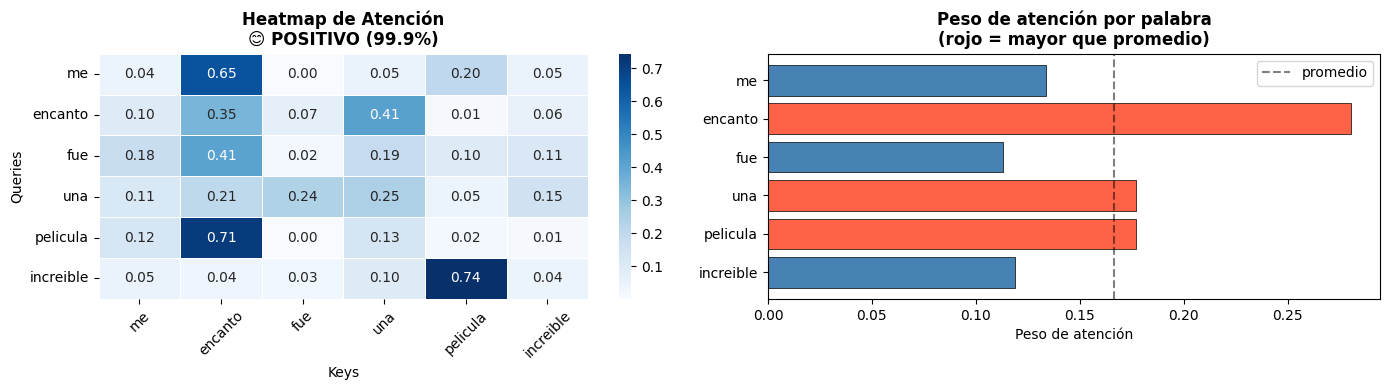

(1, 0.9993544220924377)

In [29]:
# ── 12. Probar con oraciones nuevas ───────────────────────────
print("\n" + "=" * 55)
print("         PREDICCIONES CON ORACIONES NUEVAS")
print("=" * 55)

oraciones_prueba = [
    "me encanto la pelicula fue muy buena",
    "terrible pelicula muy aburrida y mala",
    "buena actuacion pero historia decepcionante",
    "increible experiencia la recomiendo mucho",
    "no me gusto nada fue horrible",
]

for oracion in oraciones_prueba:
    predecir(oracion, mostrar_heatmap=False)

# ── 13. Ver heatmap detallado de una oración ──────────────────
print("\n" + "=" * 55)
print("         ANÁLISIS DETALLADO CON HEATMAP")
print("=" * 55)
predecir("me encanto fue una pelicula increible", mostrar_heatmap=True)


         MODO INTERACTIVO
Escribí una oración para analizar su sentimiento.
Escribí 'salir' para terminar.


───────────────────────────────────────────────────────
Oración:     'La pelicula fue horrenda, no me ha generado ninguna emoción'
Predicción:  😊 POSITIVO  (64.5%)
Positivo:    64.5%
Negativo:    35.5%

Atención por palabra:
  fue             0.277  ███████████
  horrenda,       0.091  ███
  ha              0.091  ███
  generado        0.091  ███
  ninguna         0.091  ███
  emoción         0.091  ███
  no              0.079  ███
  me              0.067  ██
  la              0.064  ██
  pelicula        0.059  ██


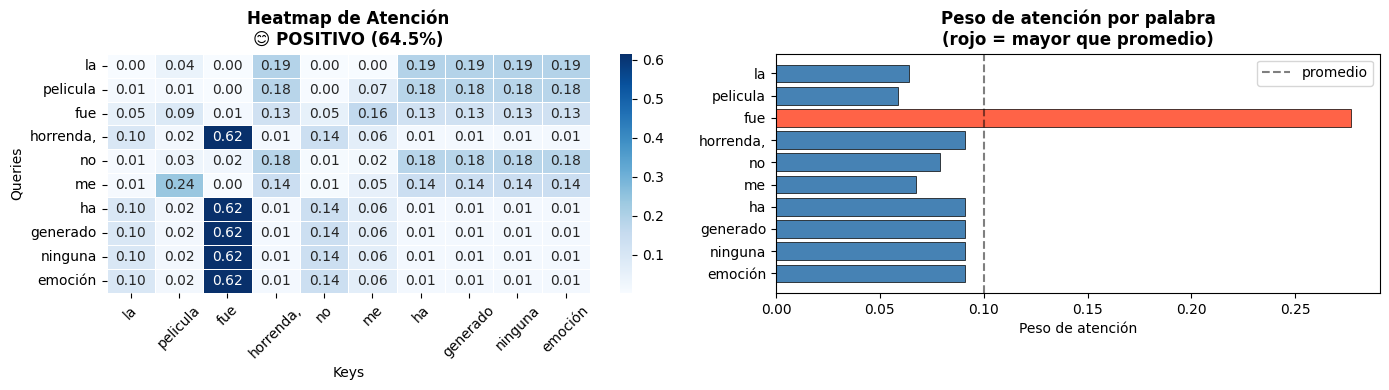

In [ ]:
# ── 14. Modo interactivo ──────────────────────────────────────
from IPython.display import clear_output

print("\n" + "=" * 55)
print("         MODO INTERACTIVO")
print("=" * 55)
print("Escribí una oración para analizar su sentimiento.")
print("Escribí 'salir' para terminar.\n")

while True:
    texto = input("✍️  Tu oración: ").strip()

    if texto.lower() == 'salir':
        print("👋 Saliendo del modo interactivo.")
        break

    if len(texto.split()) < 2:
        print("⚠️  Escribí al menos 2 palabras.\n")
        continue

    print()
    predecir(texto, mostrar_heatmap=True)
    print()